# Домашнее задание 1. Базовые компоненты нейронных сетей



Домашнее задание состоит из 9 задач, разделенных на три уровня сложности:

| Уровень | Задачи | Баллы               |
|---------|--------|---------------------|
| **Простые** | 1—4    | 3 ( 0.75 за задачу) |
| **Средние** | 5—7    | 3 (1 за задачу)     |
| **Сложные** | 8—9    | 4 (2 за задачу)     |

**Итого:** 10 баллов

## Настройка окружения

In [2]:
# Импорты
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.datasets import make_moons, make_circles
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, confusion_matrix, roc_auc_score,
    mean_squared_error, mean_absolute_error,
    recall_score
)
import seaborn as sns
import random
import warnings
warnings.filterwarnings('ignore')

# Фиксируем seed
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)

---

# ПРОСТЫЕ ЗАДАЧИ (1—4)

Эти задачи на понимание базовых концепций: линейные функции, активации, градиентный спуск.

## Задача 1. Линейная функция и нейрон

### Постановка задачи

Обучите простейший линейный классификатор (один нейрон без скрытых слоев) на двумерных данных.

**Теоретический минимум:**
- Линейный нейрон: $y = w_1 x_1 + w_2 x_2 + b$
- Сигмоида для бинарной классификации: $\sigma(z) = \frac{1}{1 + e^{-z}}$
- Бинарная кросс-энтропия: $L = -\frac{1}{N} \sum [y \log(\hat{y}) + (1-y) \log(1-\hat{y})]$

### Задача
1. Сгенерируйте две линейно разделимые двумерные выборки (используйте `make_moons` или нарисуйте сами).
2. Обучите линейный классификатор (используйте PyTorch или NumPy).
3. Визуализируйте:
   - Исходные точки двух классов.
   - Разделяющую линию (границу решения).
4. Выведите финальную точность (Accuracy) на тестовой выборке.

**Подсказка:** `torch.nn.Linear`, `torch.nn.BCEWithLogitsLoss`

Test accuracy: 1.000


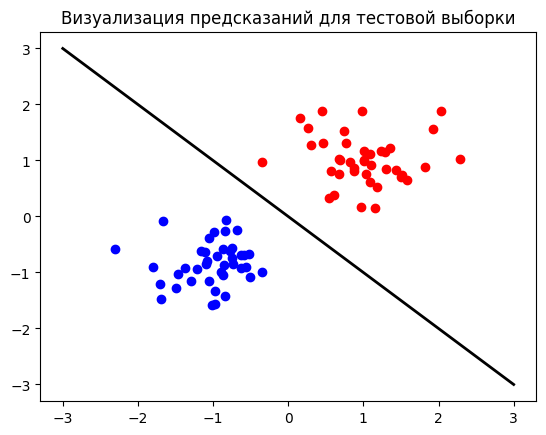

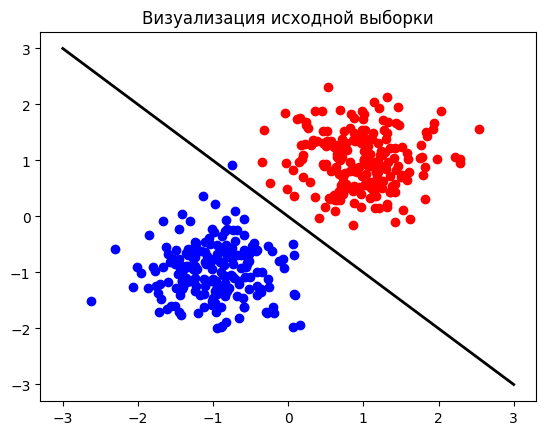

In [ ]:
# Задача 1. Линейная функция и нейрон (решение)

n = 400
cov = np.array([[0.25, 0.0],[0.0, 0.25]])
x0 = np.random.multivariate_normal(mean=[-1.0, -1.0], cov=cov, size=n//2)
x1 = np.random.multivariate_normal(mean=[ 1.0,  1.0], cov=cov, size=n//2)

# ваш код здесь

# метки отрицательного класса
arr0 = np.zeros(n//2)
arr0 = arr0[:, np.newaxis]
data_0 = np.concatenate((x0, arr0), axis=1)

# метки положительного класса
arr1 = np.ones(n//2)
arr1 = arr1[:, np.newaxis]
data_1 = np.concatenate((x1, arr1), axis=1)

# формирование выборок
data = np.concatenate((data_0, data_1), axis=0)
X, y = data[:, :2], data[:, 2]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42,
)
X_train = torch.FloatTensor(X_train)
y_train = torch.FloatTensor(y_train)
X_test = torch.FloatTensor(X_test)
y_test = torch.FloatTensor(y_test)


class SimpleClassifier(nn.Module):
    """Простой классификатор"""
    def __init__(self):
        super().__init__()
        self.model_lin = nn.Linear(2, 1)
        self.model_act = nn.Sigmoid()

    def forward(self, x):
        x = self.model_lin(x)
        x = self.model_act(x)
        return x


simple_class = SimpleClassifier()
optimizer = torch.optim.Adam(simple_class.parameters(), lr=0.01)
criterion = nn.BCELoss()

# Поиск весов
simple_class.train()
for epoch_index in range(10000):
    optimizer.zero_grad()
    y_pred_train = simple_class.forward(X_train)
    loss = criterion(y_pred_train.flatten(), y_train)
    loss.backward()
    optimizer.step()

# Классификация тестовой выборки
simple_class.eval()
with torch.no_grad():
    probs_test = simple_class(X_test)

probs_np = probs_test.detach().numpy()
y_pred_test = (probs_np >= 0.5).astype(int)
mask = y_pred_test > 0
mask = mask.ravel()
x1_pred_test = X_test[mask]
x0_pred_test = X_test[~mask]

acc = accuracy_score(y_test, y_pred_test)# ваш код здесь
print(f"Test accuracy: {acc:.3f}")

# ваш код здесь
plt.scatter(x0_pred_test[:, 0], x0_pred_test[:, 1], color='blue')
plt.scatter(x1_pred_test[:, 0], x1_pred_test[:, 1], color='red')
plt.plot([-3, 3], [3, -3], color='black', linewidth=2,)
plt.title("Визуализация предсказаний для тестовой выборки")
plt.show()

plt.scatter(x0[:, 0], x0[:, 1], color='blue')
plt.scatter(x1[:, 0], x1[:, 1], color='red')
plt.plot([-3, 3], [3, -3], color='black', linewidth=2,)
plt.title("Визуализация исходной выборки")
plt.show()


## Задача 2. Активационные функции

### Постановка задачи

Реализуйте три активационные функции вручную и визуализируйте их.

**Теоретический минимум:**
- ReLU: $f(x) = \max(0, x)$
- Sigmoid: $f(x) = \frac{1}{1 + e^{-x}}$
- Tanh: $f(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}}$

### Задача
1. Реализуйте три функции в NumPy.
2. Для диапазона $x \in [-5, 5]$:
   - Вычислите значения функций.
   - Постройте график с тремя кривыми.
3. Укажите на графике:
   - Диапазон значений (range).
   - Поведение на краях (асимптоты).
4. **Вывод:** Какая функция лучше для скрытых слоев? Почему?

**Подсказка:** `np.linspace`, `plt.plot`, `plt.grid`

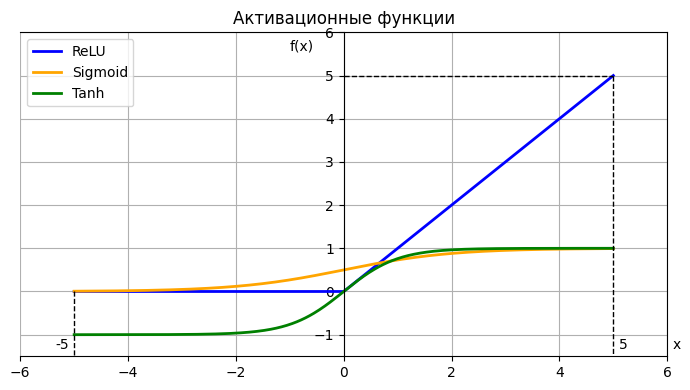

In [ ]:
# Задача 2. Активационные функции (решение)

def relu(x):
    assert "ваш код здесь"
    y = x.copy()
    y[y < 0] = 0
    return y

def sigmoid(x):
    assert "ваш код здесь"
    y = 1 / (1 + np.exp(-x))
    return y

def tanh(x):
    assert "ваш код здесь"
    y = (np.exp(x) - np.exp(-x)) / (np.exp(x) + np.exp(-x))
    return y

x = np.linspace(-5, 5, 500)

plt.figure(figsize=(7, 4))

# ваш код здесь
y_relu = relu(x)
y_sigmoid = sigmoid(x)
y_tanh = tanh(x)
plt.plot(x, y_relu, color='blue', linewidth=2, label='ReLU')
plt.plot(x, y_sigmoid, color='orange', linewidth=2, label='Sigmoid')
plt.plot(x, y_tanh, color='green', linewidth=2, label='Tanh')

plt.plot(
    [0, 5], [np.max(y_relu), np.max(y_relu)],
    color='black', linestyle='--', linewidth=1
)
plt.plot(
    [-5, -5], [np.min(y_relu), -1.5],
    color='black', linestyle='--', linewidth=1
)
plt.plot(
    [5, 5], [np.max(y_relu), -1.5],
    color='black', linestyle='--', linewidth=1
)

ax = plt.gca()
ax.axis([-6, 6, -1.5, 6])
ax.spines['left'].set_position('center')

ax.text(
        -5.1,
        -1.4,
        '-5',
        ha='right',
        va='bottom'
)
ax.text(
        5.1,
        -1.4,
        '5',
        ha='left',
        va='bottom'
)
ax.text(
        6.1,
        -1.4,
        'x',
        ha='left',
        va='bottom'
)
ax.text(
        -1,
        5.5,
        'f(x)',
        ha='left',
        va='bottom'
)

plt.legend()
plt.grid(True)
plt.title("Активационные функции")
plt.tight_layout()
plt.show()

## Задача 3. Forward pass через сеть

### Постановка задачи

Реализуйте forward pass для полносвязной сети вручную с NumPy.

**Теоретический минимум:**
- Layer: $z = Wx + b$
- Network: $h = \sigma(z) = \sigma(W_1 x + b_1)$, затем $\hat{y} = W_2 h + b_2$

### Задача
1. Создайте сеть архитектуры: **Input (2) → Hidden (8, ReLU) → Output (1, Sigmoid)**.
2. Инициализируйте веса случайно.
3. Реализуйте forward pass для одного батча (например, 32 примера).
4. Проверьте размеры:
   - Исходный батч: (32, 2).
   - После скрытого слоя: (32, 8).
   - На выходе: (32, 1).
5. Выведите пример вывода для первых 5 примеров.

**Подсказка:** не используйте PyTorch, только NumPy.

In [ ]:
# Задача 3. Forward pass через сеть (решение, NumPy)

rng = np.random.default_rng(SEED)

# ваш код здесь
W1 = np.random.randn(2, 8)
b1 = np.random.randn(1, 8)
W2 = np.random.randn(8, 1)
b2 = np.random.randn(1, 1)


def relu_np(z):
    assert "ваш код здесь"
    y = z.copy()
    y[y < 0] = 0
    return y

def sigmoid_np(z):
    assert "ваш код здесь"
    y = 1 / (1 + np.exp(-z))
    return y

# ваш код здесь
# генерация выборки
n = 32
cov = np.array([[0.25, 0.0],[0.0, 0.25]])
x0 = np.random.multivariate_normal(mean=[-1.0, -1.0], cov=cov, size=n//2)
x1 = np.random.multivariate_normal(mean=[ 1.0,  1.0], cov=cov, size=n//2)
Xb = np.concatenate((x0, x1), axis=0)
np.random.shuffle(Xb)

# Выход скрытого слоя с активацией
h = Xb @ W1 + b1
h = relu_np(h)

# Выход нейросети
y_hat = h @ W2 + b2
y_hat = sigmoid_np(y_hat)

print("Input batch shape:", Xb.shape)
print("Hidden activations shape:", h.shape)
print("Output shape:", y_hat.shape)
print("\nПример выхода (первые 5 примеров):")
print(y_hat[:5])

Input batch shape: (32, 2)
Hidden activations shape: (32, 8)
Output shape: (32, 1)

Пример выхода (первые 5 примеров):
[[9.76523511e-01]
 [6.82598394e-04]
 [4.80973206e-03]
 [3.54959845e-03]
 [1.11521040e-03]]


## Задача 4. Матрично-векторные операции

### Постановка задачи

Разберитесь с broadcasting в NumPy и визуализируйте результаты.

**Теоретический минимум:**
- Broadcasting — автоматическое расширение размеров массивов.
- Важно для батчевых операций.

### Задача
1. Создайте:
   - Вектор весов: shape (5,).
   - Батч данных: shape (10, 5).
   - Смещение: shape (1,).
2. Вычислите: $z = X \cdot w + b$ (матричное произведение + смещение).
3. Объясните, как работает broadcasting при добавлении смещения.
4. Проверьте, что результат имеет shape (10,).
5. **Вывод:** Что происходит, если забыть о правильном reshape при broadcasting?

**Подсказка:** `np.dot`, `np.reshape`, проверьте `.shape`

In [ ]:
# Задача 4. Матрично-векторные операции (решение)

w = np.random.randn(5)           # (5,)
X = np.random.randn(10, 5)       # (10, 5)
b = np.array([0.3])              # (1,)


# ваш код здесь
z = np.dot(X, w) + b
print("w.shape:", w.shape)
print("X.shape:", X.shape)
print("b.shape:", b.shape)
print("z.shape:", z.shape)

w_col = w.reshape(5, 1)
z_wrong = np.dot(X, w_col) + b
print("Если w сделать столбцом, получаем shape:", z_wrong.shape)

z_fixed = z_wrong.ravel()
print("Исправили reshape ->", z_fixed.shape)

w.shape: (5,)
X.shape: (10, 5)
b.shape: (1,)
z.shape: (10,)
Если w сделать столбцом, получаем shape: (10, 1)
Исправили reshape -> (10,)


**Вывод:**    
 Если забыть о правильном reshape при broadcasting, то у результата матричной операции может появляться дополнительное лишнее измерение.

---

# СРЕДНИЕ ЗАДАЧИ (5—7)

Эти задачи требуют комбинирования нескольких концепций и анализа поведения сетей.

## Задача 5. Решение задачи XOR

### Постановка задачи

XOR не разделим линейно. Постройте сеть, которая это решает.

**Теоретический минимум:**
- XOR требует скрытого слоя с хотя бы 2–3 нейронами.
- Геометрически: скрытый слой преобразует пространство, делая классы линейно разделимыми.

### Задача
1. Создайте XOR датасет: четыре точки (0,0)→0, (0,1)→1, (1,0)→1, (1,1)→0.
2. Постройте сеть: **Input(2) → Hidden(4, ReLU) → Output(1, Sigmoid)**.
3. Обучите сеть (≈1000 итераций).
4. Визуализируйте:
   - Исходные точки.
   - Предсказания модели в виде heatmap'а в области [0,1]×[0,1].
5. Выведите финальные потери и точность.

**Подсказка:** `torch.optim.SGD` или `Adam`, learning rate ≈ 0.1-0.5

Final loss: 0.000567
Accuracy:   1.000
Predictions (prob): [0.0005803704261779785, 0.9994346499443054, 0.9994314312934875, 0.0005538418772630394]


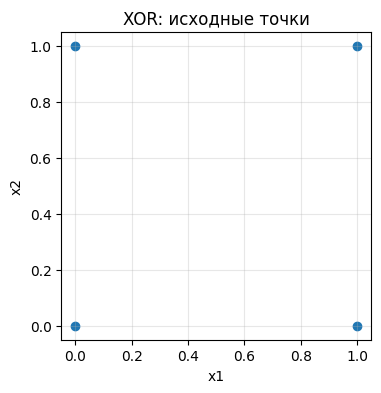

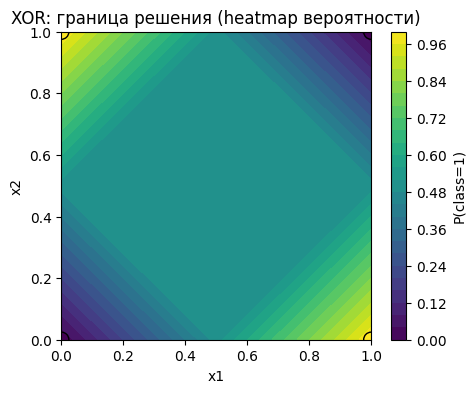

In [ ]:
# Задача 5. Решение XOR (решение)

X_xor = torch.tensor([[0.,0.],
                      [0.,1.],
                      [1.,0.],
                      [1.,1.]], dtype=torch.float32)
y_xor = torch.tensor([[0.],
                      [1.],
                      [1.],
                      [0.]], dtype=torch.float32)

class XORNet(nn.Module):
    assert "ваш код здесь"
    def __init__(self, n_hidden_neurons):
        super().__init__()
        self.n_hidden_neurons = n_hidden_neurons
        self.model_lin1 = nn.Linear(2, n_hidden_neurons)
        self.model_act1 = nn.ReLU()
        self.model_lin2 = nn.Linear(n_hidden_neurons, 1)
        self.model_act2 = nn.Sigmoid()

    def forward(self, x):
        x = self.model_lin1(x)
        x = self.model_act1(x)
        x = self.model_lin2(x)
        x = self.model_act2(x)
        return x

model_xor = XORNet(4)
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model_xor.parameters(), lr=0.01)


loss_history = []
probs_lst = []

# Обучение
model_xor.train()
for epoch in range(2000):
    optimizer.zero_grad()
    y_pred_train = model_xor.forward(X_xor)
    loss = criterion(y_pred_train.flatten(), y_xor.flatten())
    loss_history.append(loss)
    probs_lst.append(y_pred_train)
    loss.backward()
    optimizer.step()
probs = torch.cat(probs_lst, dim=1)

# Инференс
model_xor.eval()

with torch.no_grad(): #ваш код здесь
    probs_test = model_xor(X_xor)

probs_np = probs_test.detach().numpy()
y_pred_test = (probs_np >= 0.5).astype(int)
acc = accuracy_score(y_xor.numpy(), y_pred_test)

# ваш код здесь

print(f"Final loss: {loss_history[-1]:.6f}")
print(f"Accuracy:   {acc:.3f}")
print("Predictions (prob):", probs[:, -1].tolist())


plt.figure(figsize=(4, 4))
plt.scatter(X_xor[:, 0], X_xor[:, 1])
plt.title("XOR: исходные точки")
plt.xlabel("x1"); plt.ylabel("x2")
plt.grid(True, alpha=0.3)
plt.show()


with torch.no_grad(): # ваш код здесь
    grid_probs = model_xor(X_xor)

xx, yy = np.unique(X_xor.numpy()), np.unique(X_xor.numpy())
grid_probs_np = grid_probs.numpy()
grid_probs = grid_probs_np.reshape(2, 2)
plt.figure(figsize=(5, 4))
plt.contourf(xx, yy, grid_probs, levels=30)
plt.colorbar(label="P(class=1)")
plt.scatter(X_xor[:,0], X_xor[:,1], c=y_xor.view(-1), s=120, edgecolor="k")
plt.title("XOR: граница решения (heatmap вероятности)")
plt.xlabel("x1"); plt.ylabel("x2")
plt.show()


## Задача 6. Анализ трансформации признаков

### Постановка задачи

Визуализируйте, как скрытый слой преобразует исходное пространство.

### Задача
1. Возьмите обученную сеть из задачи 6.
2. Получите активации скрытого слоя для всех точек данных.
3. Визуализируйте в виде scatter plot в пространстве признаков скрытого слоя.
4. Покажите 2D проекцию (первые два нейрона скрытого слоя).
5. **Вывод:** Как изменилось взаимное расположение классов? Стали ли они линейно разделимы?

**Подсказка:** используйте `model.fc1` для получения скрытого слоя.

Активации скрытого слоя для всех точек данных:
tensor([[2.4072e+00, 1.2573e+00, 0.0000e+00, 0.0000e+00],
        [0.0000e+00, 3.3984e+00, 0.0000e+00, 6.7711e-05],
        [4.0531e-05, 3.3971e+00, 0.0000e+00, 5.6410e-04],
        [0.0000e+00, 5.5382e+00, 0.0000e+00, 3.4028e+00]])


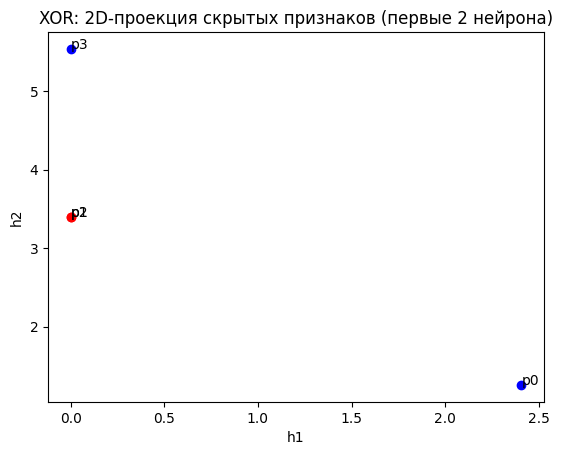

In [ ]:
# Задача 6. Анализ трансформации признаков (решение)

model_xor.eval()
with torch.no_grad(): # ваш код здесь
    H = model_xor.model_lin1(X_xor)
    H = model_xor.model_act1(H)

print('Активации скрытого слоя для всех точек данных:')
print(H)

# Точки, несоответствующие XOR
plt.scatter(
    [H[0, 0], H[3, 0]],
    [H[0, 1], H[3, 1]],
    color='blue'
)

# Точки, соответствующие XOR
plt.scatter(
    [H[1, 0], H[2, 0]],
    [H[1, 1], H[2, 1]],
    color='red'
)

plt.text(H[0, 0], H[0, 1], 'p0')
plt.text(H[1, 0], H[1, 1], 'p1')
plt.text(H[2, 0], H[2, 1], 'p2')
plt.text(H[3, 0], H[3, 1], 'p3')
plt.xlabel("h1"); plt.ylabel("h2")
plt.title("XOR: 2D-проекция скрытых признаков (первые 2 нейрона)")

plt.show()


**Вывод:**    
 В проекции h1-h2 пространства признаков скрытого слоя точки p1(0; 1) и p2(1; 0) практически слились в одну точку, что обеспечило линейную разделимость для задачи XOR.

## Задача 7. Классификация датасета moon

### Постановка задачи

Работайте с более сложной задачей: датасет make_moons.

### Задача
1. Загрузите датасет: `make_moons(n_samples=300, noise=0.1, random_state=SEED)`.
2. Нормализуйте данные (StandardScaler).
3. Постройте сеть с архитектурой на ваш выбор (≥2 скрытых слоя).
4. Обучите модель на 100+ итерациях с tracking потерь.
5. Визуализируйте:
   - График потерь (Loss vs итерация).
   - Границы решения (heatmap).
   - Исходные точки поверх границ.
6. Выведите Accuracy на тестовой выборке.

**Подсказка:** попробуйте разные размеры скрытых слоёв и learning rate.

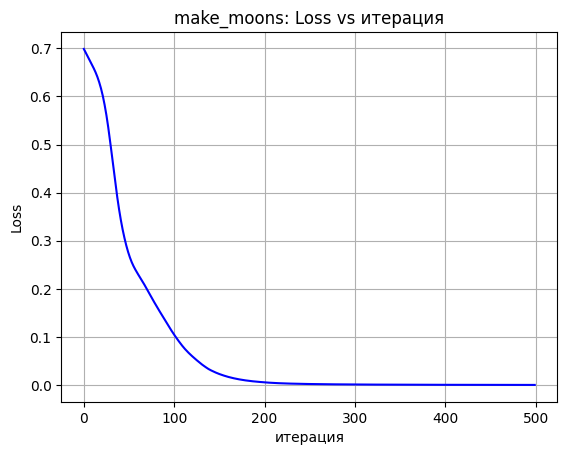

Test accuracy: 1.00


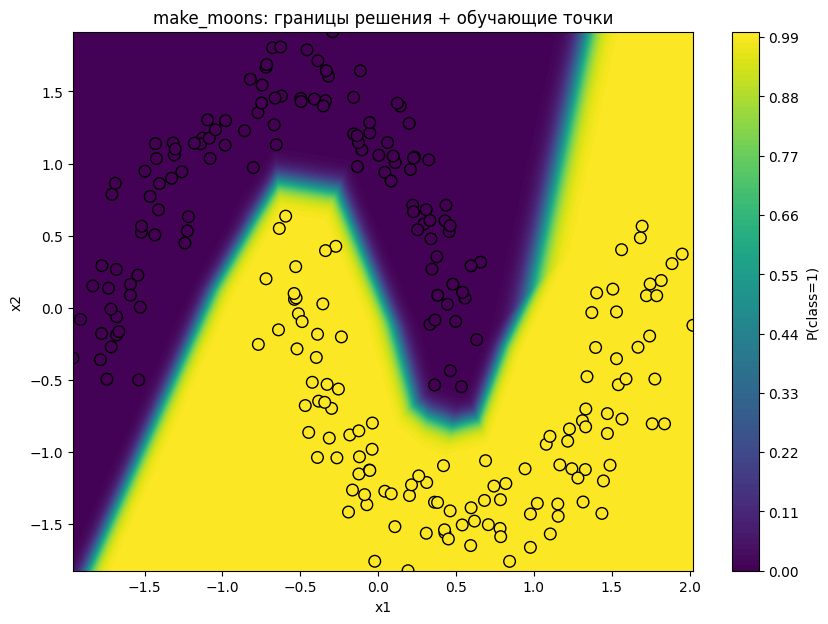

In [ ]:
# Задача 7. Классификация make_moons (решение)

X, y = make_moons(n_samples=300, noise=0.1, random_state=SEED)
scaler = StandardScaler() # ваш код здесь
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    stratify=y,
    test_size=0.2,
    random_state=42
)
X_train = scaler.fit_transform(X_train)
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)
X_test = scaler.transform(X_test)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

class NextClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.model_lin1 = nn.Linear(2, 10)
        self.model_act1 = nn.ReLU()
        self.model_lin2 = nn.Linear(10, 5)
        self.model_act2 = nn.ReLU()
        self.model_lin3 = nn.Linear(5, 1)
        self.model_act3 = nn.Sigmoid()

    def forward(self, x):
        x = self.model_lin1(x)
        x = self.model_act1(x)
        x = self.model_lin2(x)
        x = self.model_act2(x)
        x = self.model_lin3(x)
        x = self.model_act3(x)

        return x

model_class2 = NextClassifier()
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model_class2.parameters(), lr=0.01)

loss_history = []

model_class2.train()
for epoch in range(500):
    optimizer.zero_grad()
    y_pred_train = model_class2.forward(X_train)
    loss = criterion(y_pred_train.flatten(), y_train.flatten())
    loss_history.append(loss)
    loss.backward()
    optimizer.step()

# Инференс
model_class2.eval()
with torch.no_grad(): #ваш код здесь
    probs_test = model_class2(X_test)

probs_np = probs_test.detach().numpy()
y_pred_test = (probs_np >= 0.5).astype(int)
acc = accuracy_score(y_test.numpy(), y_pred_test)

# График Loss
loss_history_formatted = list(map(lambda x: x.detach().numpy(), loss_history))
iterations = np.arange(0, 500, 1)
plt.plot(
    iterations, loss_history_formatted ,
    color='blue',
)

plt.grid(True)
plt.title("make_moons: Loss vs итерация")
plt.xlabel("итерация"); plt.ylabel("Loss")
plt.show()

print(f'Test accuracy: {acc:.2f}')


X_train_np = X_train.numpy()
x_min = np.min(X_train_np[:,0])
x_max = np.max(X_train_np[:,0])
y_min = np.min(X_train_np[:,1])
y_max = np.max(X_train_np[:,1])
xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300),
)
grid_points = np.c_[xx.ravel(), yy.ravel()]
grid_tensor = torch.tensor(grid_points, dtype=torch.float32)

model_class2.eval()
with torch.no_grad():
    grid_probs = model_class2(grid_tensor).numpy().reshape(xx.shape)
plt.figure(figsize=(10, 7))
plt.contourf(xx, yy, grid_probs, levels=100)
plt.colorbar(label="P(class=1)")
plt.scatter(X_train[:,0], X_train[:,1], c=y_train.view(-1), s=70, edgecolor="k")
plt.title("make_moons: границы решения + обучающие точки")
plt.xlabel("x1"); plt.ylabel("x2")
plt.show()

# ЗАДАЧИ ВЫСОКОЙ СЛОЖНОСТИ НА ФУНКЦИИ ПОТЕРЬ В PYTORCH (8—9)


## Общая информация
- **Цель:** понять когда и почему использовать разные функции потерь.

---

---

# ЗАДАЧА 8. Комбинированная функция потерь (MSE + L1)

## Условие
Дана задача регрессии с 12 признаками. Нужно построить модель, которая минимизирует комбинированный loss: 70% MSE + 30% L1. Эта комбинация позволяет получить лучший баланс между сглаживанием и робастностью.

**Требования:**
1. Архитектура: 12 → 32 → 16 → 1.
2. Loss = 0.7 * MSE + 0.3 * MAE.
3. Оптимизатор: Adam (lr=0.01).
4. Количество эпох: 100.
5. Сравнить с чистым MSE и MAE.
6. Вывести: финальное RMSE и MAE на тесте.

## Теоретический минимум. Комбинированные Loss

### Определение
$$L = \alpha \cdot L_1(y, \hat{y}) + (1-\alpha) \cdot L_2(y, \hat{y})$$

Пример: $L = 0.7 \cdot \text{MSE} + 0.3 \cdot \text{MAE}$

### Интуиция
- Комбинируем преимущества разных функций потерь.
- MSE (70%): более сильно штрафует за большие ошибки.
- MAE (30%): добавляет робастность к выбросам.
- Выбор альфа зависит от конкретной задачи и данных.

### Когда использовать
- Когда нужна оптимизация по нескольким метрикам.
- Когда нужна компромисс между требованиями.
- Многозадачное обучение (multi-task learning).
- Когда данные содержат некоторые выбросы, но не критично.

### Реализация в PyTorch
```python
def combined_loss(pred, target, alpha=0.7):
    mse = F.mse_loss(pred, target)
    mae = F.l1_loss(pred, target)
    return alpha * mse + (1 - alpha) * mae

for epoch in range(epochs):
    loss = combined_loss(pred, target)
    loss.backward()
```

---

Результаты для Loss по MSE
RMSE train: 0.126
MAE train: 0.095
RMSE test: 1.729
MAE test: 1.375
Результаты для Loss по MAE
RMSE train: 0.604
MAE train: 0.329
RMSE test: 1.394
MAE test: 1.065
Результаты для комбинированного Loss
RMSE train: 0.247
MAE train: 0.166
RMSE test: 1.600
MAE test: 1.245


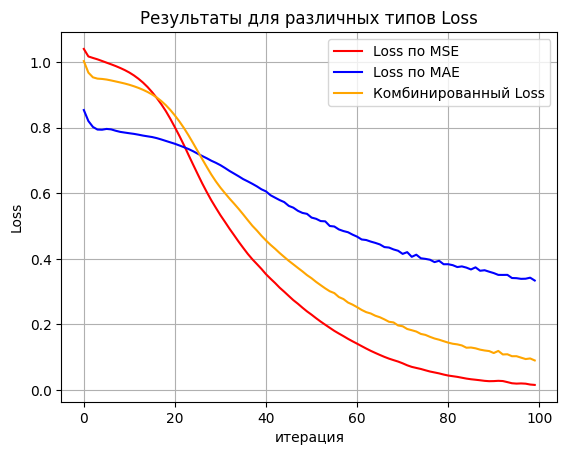

In [ ]:
# Задача 8. Комбинированная функция потерь (0.7*MSE + 0.3*L1)

# ваш код здесь
X = np.random.randn(500, 12)
y = np.random.randn(500)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

class SimpleRegressor(nn.Module):
    def __init__(self):
        super().__init__()
        self.model_lin1 = nn.Linear(12, 32)
        self.model_act1 = nn.Tanh()
        self.model_lin2 = nn.Linear(32, 16)
        self.model_act2 = nn.Tanh()
        self.model_lin3 = nn.Linear(16, 1)

    def forward(self, x):
        x = self.model_lin1(x)
        x = self.model_act1(x)
        x = self.model_lin2(x)
        x = self.model_act2(x)
        x = self.model_lin3(x)

        return x

mse = nn.MSELoss()
mae = nn.L1Loss(reduction='mean')

def combined_loss(pred, target, alpha=0.7):
    loss = alpha*mse(pred, target) + (1 - alpha)*mae(pred, target)
    return loss


# Расчёты для Loss по MSE
model_reg_mse = SimpleRegressor()
optimizer = torch.optim.Adam(model_reg_mse.parameters(), lr=0.01)
loss_history_mse = []
model_reg_mse.train()
for epoch in range(100):
    optimizer.zero_grad()
    y_pred_train = model_reg_mse.forward(X_train)
    loss = mse(y_pred_train.flatten(), y_train.flatten())
    loss_history_mse.append(loss)
    loss.backward()
    optimizer.step()

# Инференс
model_reg_mse.eval()
with torch.no_grad(): #ваш код здесь
    y_pred_train = model_reg_mse(X_train)
    y_pred_test = model_reg_mse(X_test)

rmse_train = mean_squared_error(y_train.numpy(), y_pred_train.numpy()) ** 0.5
mae_train = mean_absolute_error(y_train.numpy(), y_pred_train.numpy())
rmse_test = mean_squared_error(y_test.numpy(), y_pred_test.numpy()) ** 0.5
mae_test = mean_absolute_error(y_test.numpy(), y_pred_test.numpy())
print('Результаты для Loss по MSE')
print(f'RMSE train: {rmse_train:.3f}')
print(f'MAE train: {mae_train:.3f}')
print(f'RMSE test: {rmse_test:.3f}')
print(f'MAE test: {mae_test:.3f}')


# Расчёты для Loss по MAE
model_reg_mae = SimpleRegressor()
optimizer = torch.optim.Adam(model_reg_mae.parameters(), lr=0.01)
loss_history_mae = []
model_reg_mae.train()
for epoch in range(100):
    optimizer.zero_grad()
    y_pred_train = model_reg_mae.forward(X_train)
    loss = mae(y_pred_train.flatten(), y_train.flatten())
    loss_history_mae.append(loss)
    loss.backward()
    optimizer.step()

# Инференс
model_reg_mae.eval()
with torch.no_grad(): #ваш код здесь
    y_pred_train = model_reg_mae(X_train)
    y_pred_test = model_reg_mae(X_test)

rmse_train = mean_squared_error(y_train.numpy(), y_pred_train.numpy()) ** 0.5
mae_train = mean_absolute_error(y_train.numpy(), y_pred_train.numpy())
rmse_test = mean_squared_error(y_test.numpy(), y_pred_test.numpy()) ** 0.5
mae_test = mean_absolute_error(y_test.numpy(), y_pred_test.numpy())
print('Результаты для Loss по MAE')
print(f'RMSE train: {rmse_train:.3f}')
print(f'MAE train: {mae_train:.3f}')
print(f'RMSE test: {rmse_test:.3f}')
print(f'MAE test: {mae_test:.3f}')


# Расчёты для комбинированного Loss
model_reg_comb = SimpleRegressor()
optimizer = torch.optim.Adam(model_reg_comb.parameters(), lr=0.01)
loss_history_comb = []
model_reg_comb.train()
for epoch in range(100):
    optimizer.zero_grad()
    y_pred_train = model_reg_comb.forward(X_train)
    loss = combined_loss(y_pred_train.flatten(), y_train.flatten())
    loss_history_comb.append(loss)
    loss.backward()
    optimizer.step()

# Инференс
model_reg_comb.eval()
with torch.no_grad(): #ваш код здесь
    y_pred_train = model_reg_comb(X_train)
    y_pred_test = model_reg_comb(X_test)

rmse_train = mean_squared_error(y_train.numpy(), y_pred_train.numpy()) ** 0.5
mae_train = mean_absolute_error(y_train.numpy(), y_pred_train.numpy())
rmse_test = mean_squared_error(y_test.numpy(), y_pred_test.numpy()) ** 0.5
mae_test = mean_absolute_error(y_test.numpy(), y_pred_test.numpy())
print('Результаты для комбинированного Loss')
print(f'RMSE train: {rmse_train:.3f}')
print(f'MAE train: {mae_train:.3f}')
print(f'RMSE test: {rmse_test:.3f}')
print(f'MAE test: {mae_test:.3f}')


# График Loss
loss_history_mse_formatted = list(
    map(lambda x: x.detach().numpy(), loss_history_mse)
)
loss_history_mae_formatted = list(
    map(lambda x: x.detach().numpy(), loss_history_mae)
)
loss_history_comb_formatted = list(
    map(lambda x: x.detach().numpy(), loss_history_comb)
)

iterations = np.arange(0, 100, 1)
plt.plot(
    iterations, loss_history_mse_formatted,
    color='red', label='Loss по MSE'
)
plt.plot(
    iterations, loss_history_mae_formatted,
    color='blue', label='Loss по MAE'
)
plt.plot(
    iterations, loss_history_comb_formatted,
    color='orange', label='Комбинированный Loss'
)

plt.grid(True)
plt.legend()
plt.title("Результаты для различных типов Loss")
plt.xlabel("итерация"); plt.ylabel("Loss")
plt.show()

**Вывод:**    
1 Наиболее интенсивное снижение Loss происходит по MSE.  
2 Для заданного числа итераций применение MSE обеспечивает наибольшее снижение Loss.    
3 На тестовой выборке наибольшую точность по метрикам RMSE и MAE обеспечивает нейросеть, для которой при обучении использовался Loss по MAE, наименьшую точность - Loss по MSE.

---

# ЗАДАЧА 9. Классификация с дисбалансом (Weighted CrossEntropyLoss)

## Условие
Дана выборка из 500 примеров с бинарной классификацией, где 90% примеров принадлежат классу 0 (отрицательные), а 10% — классу 1 (положительные). Класс 1 недопредставлен. Нужно обучить модель, которая правильно предсказывает оба класса, несмотря на дисбаланс.

**Требования:**
1. Архитектура: 10 → 32 → 16 → 2.
2. Loss: CrossEntropyLoss с weight=class_weights.
3. Веса классов вычисляются как: weight = num_classes / count_per_class.
4. Оптимизатор: Adam (lr=0.01).
5. Количество эпох: 100.
6. Сравнить recall для каждого класса (с weight и без weight).

## Теоретический минимум. Weighted CrossEntropyLoss

### Определение
$$L = -\sum_{i=1}^{C} w_i \cdot y_i \log(p_i)$$

где:
- $w_i$ — вес класса $i$
- Остальное — то же самое, что и CrossEntropyLoss.

### Расчет весов
Есть несколько способов:

1. **Inverse frequency:**
   $$w_i = \frac{N}{C \cdot n_i}$$
   где $N$ — всего примеров, $C$ — число классов, $n_i$ — число примеров класса $i$

2. **Простой обратный:**
   $$w_i = \frac{1}{n_i}$$

### Интуиция
- Редкие классы получают БОЛЬШИЕ веса (штраф за ошибку).
- Частые классы получают малые веса.
- Модель вынуждена уделять больше внимания редким классам.

### Когда использовать
- Дисбалансированные датасеты (часто в реальных данных).
- Когда редкий класс важнее (например, обнаружение редкой болезни).
- Когда нужна высокая recall для всех классов.

### Реализация в PyTorch
```python
# Вычисляем веса
unique, counts = np.unique(y_train, return_counts=True)
weights = len(unique) / counts  # или другая формула
weights = torch.FloatTensor(weights)

# Используем weighted loss
criterion = nn.CrossEntropyLoss(weight=weights.to(device))
logits = model(x)
loss = criterion(logits, target)
```

---

Recall тестовой выборки при обучении без использования весов: 0.000


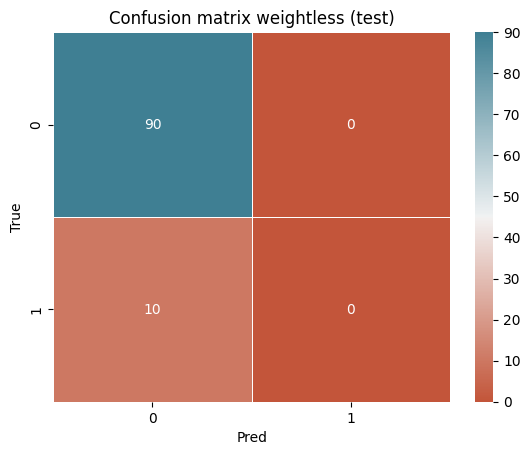

Recall тестовой выборки при обучении с использованием весов: 0.300


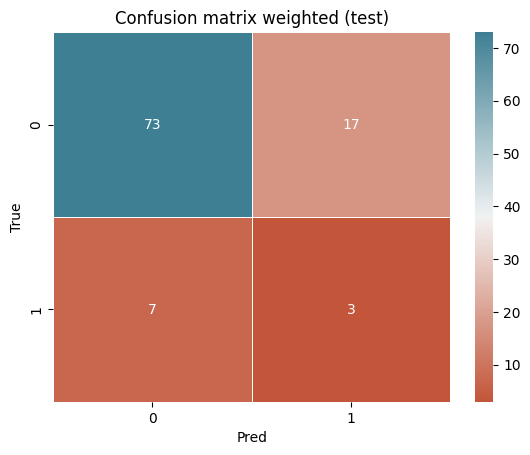

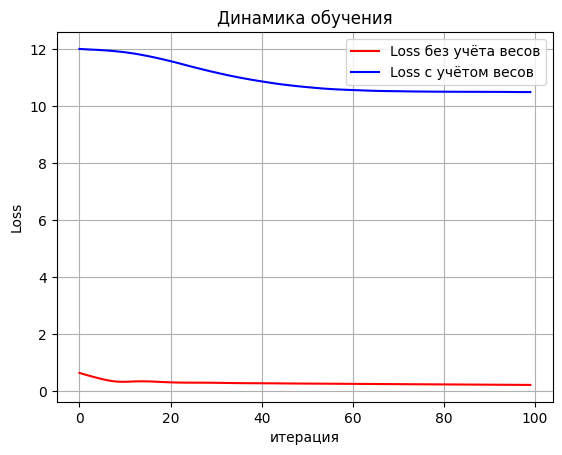

In [22]:
# Задача 9. Классификация с дисбалансом (Weighted CrossEntropyLoss) — решение

#  ваш код и выводы здесь
X = np.random.randn(500, 10)
y = np.concatenate((np.zeros(450), np.ones(50)))
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    stratify=y,
    test_size=0.2,
    random_state=42
)
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

class LastClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.model_lin1 = nn.Linear(10, 32)
        self.model_act1 = nn.ReLU()
        self.model_lin2 = nn.Linear(32, 16)
        self.model_act2 = nn.ReLU()
        self.model_lin3 = nn.Linear(16, 2)
        self.model_act3 = nn.Sigmoid()

    def forward(self, x):
        x = self.model_lin1(x)
        x = self.model_act1(x)
        x = self.model_lin2(x)
        x = self.model_act2(x)
        x = self.model_lin3(x)
        x = self.model_act3(x)

        return x


# Расчёты для Loss без учёта весов
model_class3 = LastClassifier()
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model_class3.parameters(), lr=0.01)

loss_history = []
model_class3.train()
for epoch in range(100):
    optimizer.zero_grad()
    y_pred_train = model_class3.forward(X_train)
    loss = criterion(y_pred_train[:, 1], y_train.flatten())
    loss_history.append(loss)
    loss.backward()
    optimizer.step()

# Инференс
model_class3.eval()
with torch.no_grad(): #ваш код здесь
    probs_test = model_class3(X_test)

probs_np = probs_test.detach().numpy()
y_pred_test = (probs_np[:, 1] >= 0.5).astype(int)

recall = recall_score(y_test.numpy(), y_pred_test)
print(
    f'Recall тестовой выборки при обучении \
без использования весов: {recall:.3f}'
)

# Матрица ошибок без учёта весов
conf_matrix = confusion_matrix(y_test, y_pred_test)

sns.heatmap(
    conf_matrix,
    annot=True,
    fmt='.0f',
    linewidth=.5,
    cmap=sns.diverging_palette(20, 220, as_cmap=True)
)

plt.title("Confusion matrix weightless (test)")
plt.xlabel("Pred"); plt.ylabel("True")
plt.show()


# Расчёты для Loss с учётом весов
device = "cuda" if torch.cuda.is_available() else "cpu"
device

model_class3_weight = LastClassifier()

# Вычисляем веса
unique, counts = np.unique(y_train, return_counts=True)
weights = len(unique) / counts  # или другая формула
all_weights = [weights[0] if x == 0 else weights[1] for x in y_train]
all_weights = torch.FloatTensor(all_weights)

# Используем weighted loss
criterion = nn.CrossEntropyLoss(weight=all_weights.to(device))
optimizer = torch.optim.Adam(model_class3_weight.parameters(), lr=0.01)

loss_history_weight = []
model_class3_weight.train()
for epoch in range(100):
    optimizer.zero_grad()
    y_pred_train = model_class3_weight.forward(X_train)
    loss = criterion(y_pred_train[:, 1], y_train.flatten())
    loss_history_weight.append(loss)
    loss.backward()
    optimizer.step()

# Инференс
model_class3_weight.eval()
with torch.no_grad(): #ваш код здесь
    probs_test = model_class3_weight(X_test)

probs_np = probs_test.detach().numpy()
y_pred_test = (probs_np[:, 1] >= 0.5).astype(int)

recall = recall_score(y_test.numpy(), y_pred_test)
print(
    f'Recall тестовой выборки при обучении \
с использованием весов: {recall:.3f}'
)

# Матрица ошибок с учётом весов
conf_matrix = confusion_matrix(y_test, y_pred_test)

sns.heatmap(
    conf_matrix,
    annot=True,
    fmt='.0f',
    linewidth=.5,
    cmap=sns.diverging_palette(20, 220, as_cmap=True)
)

plt.title("Confusion matrix weighted (test)")
plt.xlabel("Pred"); plt.ylabel("True")
plt.show()


# График Loss
loss_history_formatted = list(
    map(lambda x: x.detach().numpy(), loss_history)
)
loss_history_weight_formatted = list(
    map(lambda x: x.detach().numpy(), loss_history_weight)
)

iterations = np.arange(0, 100, 1)
plt.plot(
    iterations, loss_history_formatted,
    color='red', label='Loss без учёта весов'
)
plt.plot(
    iterations, loss_history_weight_formatted,
    color='blue', label='Loss с учётом весов'
)

plt.grid(True)
plt.legend()
plt.title("Динамика обучения")
plt.xlabel("итерация"); plt.ylabel("Loss")
plt.show()

Вывод:  
1 Расчёт loss с учётом весов позволяет получать более высокие ненулевые резултаты по метрике recall.  
2 При обучении без учёта весов динамика обучения выше.

---

# ИТОГОВАЯ ТАБЛИЦА: КОГДА ИСПОЛЬЗОВАТЬ КАКУЮ LOSS-ФУНКЦИЮ

| Задача | Loss Function | Когда использовать | Примеры |
|--------|---------------|--------------------|----------|
| Многоклассовая классификация (C≥2) | **CrossEntropyLoss** | Взаимно исключающие классы | Классификация изображений (MNIST), распознавание животных |
| Бинарная классификация | **BCEWithLogitsLoss** | Двуклассовая задача, один выход | Обнаружение спама, предсказание CTR |
| Регрессия с выбросами | **HuberLoss** | Данные содержат аномалии | Финансовые прогнозы, анализ датчиков |
| Многокритериальная задача | **Комбинированная** (α·L1 + (1-α)·L2) | Нужен компромисс между метриками | Multi-task learning, балансировка требований |
| Дисбалансированная классификация | **Weighted CrossEntropyLoss** | Классы недопредставлены неравномерно | Обнаружение редких болезней, fraud detection |

---

# ПОЛЕЗНЫЕ СОВЕТЫ

1. **Всегда нормализуйте признаки** (StandardScaler, MinMaxScaler).
2. **Проверяйте распределение классов** перед выбором loss.
3. **Используйте validation set** для контроля overfitting.
4. **Экспериментируйте с hyperparameters** (lr, weights, alpha).
5. **Визуализируйте learning curves** для диагностики.
6. **Не забывайте про evaluation metrics** (accuracy, precision, recall, F1, AUC).

---